In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
fear_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data.csv")


In [11]:
fear_df.shape, trades_df.shape

((2644, 4), (211224, 16))

In [24]:
fear_df.info(), trades_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IS

(None, None)

In [19]:
fear_df.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [21]:
trades_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [31]:
fear_df.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [29]:
trades_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [26]:
fear_df.duplicated().sum()
trades_df.duplicated().sum()


0

In [35]:
trades_df["Timestamp IST"] = pd.to_datetime(
    trades_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

In [41]:
trades_df["date"] = trades_df["Timestamp IST"].dt.date


In [42]:
trades_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [45]:
fear_df["date"] = pd.to_datetime(fear_df["date"])

In [46]:
fear_df["date"] = pd.to_datetime(fear_df["date"]).dt.date

In [53]:
#Daily PnL per trader (core performance metric)
daily_pnl = (
    trades_df
    .groupby(["date", "Account"])
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        total_fees=("Fee", "sum")
    )
    .reset_index()
)

In [54]:
daily_pnl.head()

,date,Account,daily_pnl,total_fees
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,12.501455
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,28.300831
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2.652489
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000,3.837189


In [49]:
#Win rate per trader (behavioral quality)
trades_df["win"] = (trades_df["Closed PnL"] > 0).astype(int)

win_rate = (
    trades_df
    .groupby(["date", "Account"])
    .agg(win_rate=("win", "mean"))
    .reset_index()
)

In [50]:
#Average trade size (risk appetite proxy)
avg_trade_size = (
    trades_df
    .groupby(["date", "Account"])
    .agg(avg_trade_usd=("Size USD", "mean"))
    .reset_index()
)

In [58]:
avg_trade_size.head()

,date,Account,avg_trade_usd
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,159.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5556.203333
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,10291.213636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5304.975000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5116.256667


In [51]:
#Leverage distribution (proxy, explained clearly)
leverage_distribution = (
    trades_df
    .groupby("date")
    .agg(
        avg_trade_usd=("Size USD", "mean"),
        p90_trade_usd=("Size USD", lambda x: x.quantile(0.9))
    )
    .reset_index()
)

In [57]:
leverage_distribution.head()

,date,avg_trade_usd,p90_trade_usd
0,2023-05-01,159.000000,178.102
1,2023-12-05,5556.203333,11822.708
2,2023-12-14,10291.213636,24884.620
3,2023-12-15,5304.975000,6395.195
4,2023-12-16,5116.256667,5764.980


In [52]:
#Number of trades per day (overtrading signal)
trades_per_day = (
    trades_df
    .groupby("date")
    .agg(total_trades=("Trade ID", "count"))
    .reset_index()
)

In [59]:
trades_per_day.head()

,date,total_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [60]:
#Long / Short ratio (directional bias)
long_short = (
    trades_df
    .groupby(["date", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

long_short["long_short_ratio"] = (
    long_short.get("Buy", 0) /
    (long_short.get("Sell", 1))
)

In [61]:
daily_trader_metrics = (
    daily_pnl
    .merge(win_rate, on=["date", "Account"], how="left")
    .merge(avg_trade_size, on=["date", "Account"], how="left")
)

In [64]:
#create fear neutral greed regimes
#create sentiment buckets
fear_df["sentiment"] = pd.cut(
    fear_df["value"],
    bins=[0, 30, 70, 100],
    labels=["Fear", "Neutral", "Greed"],
    include_lowest=True
)

In [66]:
#Merge sentiment with trader metrics
analysis_df = daily_trader_metrics.merge(
    fear_df[["date", "value", "sentiment"]],
    on="date",
    how="left"
)

In [67]:
analysis_df["sentiment"].value_counts()

sentiment
Neutral    1114
Greed       825
Fear        401
Name: count, dtype: int64

### Distribution of Market Sentiment

The dataset is primarily composed of neutral sentiment periods, with 1,114 observations, followed by greedy conditions (825) and fearful conditions (401). This indicates that the market spends most of its time in stable or moderately optimistic states, while fear-driven regimes occur less frequently.

Despite the lower frequency of fear periods, these regimes represent extreme market conditions. As a result, performance and behavioral changes observed during fear should be interpreted as responses to stress scenarios, whereas greed-related outcomes reflect more persistent market behavior.

In [68]:
#Compare trader performance across sentiment regimes
#Average PnL by sentiment
pnl_by_sentiment = (
    analysis_df
    .groupby("sentiment")
    .agg(
        avg_daily_pnl=("daily_pnl", "mean"),
        median_daily_pnl=("daily_pnl", "median")
    )
    .reset_index()
)

C:\Users\tulsi\AppData\Local\Temp\ipykernel_20020\3555613793.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sentiment")


In [71]:
pnl_by_sentiment

,sentiment,avg_daily_pnl,median_daily_pnl
0,Fear,3444.465068,142.991590
1,Neutral,4385.130535,123.305647
2,Greed,4834.207323,337.835516


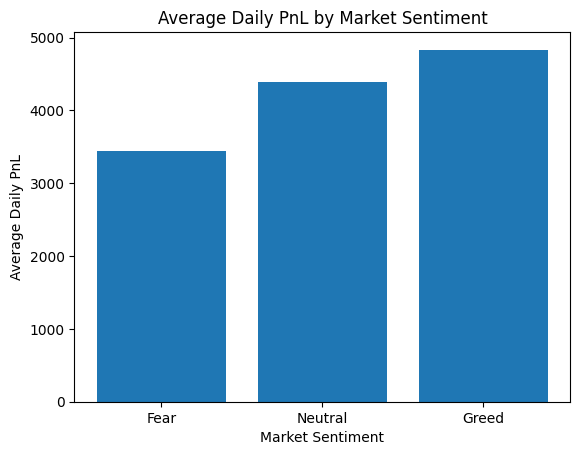

In [105]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    pnl_by_sentiment["sentiment"],
    pnl_by_sentiment["avg_daily_pnl"]
)
plt.title("Average Daily PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL")
plt.show()

### Daily PnL by Market Sentiment

Average daily PnL increases steadily from Fear to Greed, with greedy market conditions exhibiting the highest average profitability. Median PnL, however, remains relatively low across all regimes, indicating that returns are driven by a small number of high-impact days rather than consistent daily gains.

This gap between average and median PnL suggests that performance during greedy markets is more skewed, with occasional large wins offsetting many smaller outcomes.

In [69]:
#Win rate by sentiment
winrate_by_sentiment = (
    analysis_df
    .groupby("sentiment")
    .agg(avg_win_rate=("win_rate", "mean"))
    .reset_index()
)

C:\Users\tulsi\AppData\Local\Temp\ipykernel_20020\155723545.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sentiment")


In [72]:
winrate_by_sentiment

,sentiment,avg_win_rate
0,Fear,0.346802
1,Neutral,0.351703
2,Greed,0.376634


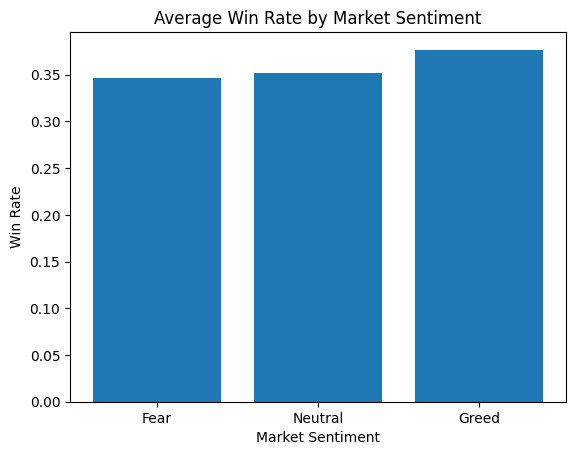

In [106]:
plt.figure()
plt.bar(
    winrate_by_sentiment["sentiment"],
    winrate_by_sentiment["avg_win_rate"]
)
plt.title("Average Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.show()

### Win Rate Across Sentiment Regimes

Average win rates increase as market sentiment shifts from fear to greed. Greedy market conditions exhibit the highest win rate (37.7%), followed by neutral (35.2%) and fearful periods (34.7%). This suggests that trending and momentum-driven environments during greedy markets allow traders to achieve a higher proportion of winning trades.

However, a higher win rate does not necessarily translate into superior overall performance. Greedy periods may also be associated with larger position sizes and increased risk-taking, where infrequent but sizable losses can outweigh the benefits of frequent small wins. Therefore, win rate should be interpreted alongside PnL and risk metrics.

In [70]:
#Average trade size by sentiment (risk-taking)
size_by_sentiment = (
    analysis_df
    .groupby("sentiment")
    .agg(avg_trade_usd=("avg_trade_usd", "mean"))
    .reset_index()
)

C:\Users\tulsi\AppData\Local\Temp\ipykernel_20020\1414717234.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sentiment")


In [73]:
size_by_sentiment

,sentiment,avg_trade_usd
0,Fear,8175.605721
1,Neutral,7484.292217
2,Greed,5735.463998


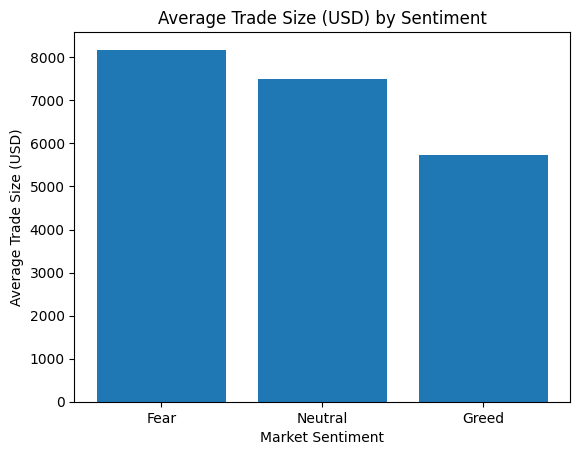

In [107]:
plt.figure()
plt.bar(
    size_by_sentiment["sentiment"],
    size_by_sentiment["avg_trade_usd"]
)
plt.title("Average Trade Size (USD) by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

### Average Trade Size Across Sentiment Regimes

Average trade size varies significantly across market sentiment regimes. Trades executed during fearful periods are the largest on average (≈ 8,176), followed by neutral conditions (≈ 7,484), while greedy periods exhibit the smallest average trade size (≈ 5,735).

This suggests that despite higher win rates during greedy markets, traders tend to reduce position sizes, potentially limiting overall profitability. In contrast, fearful markets are characterized by fewer but larger trades, reflecting heightened volatility and conviction-driven positioning. These findings highlight the importance of evaluating trade size alongside win rate when assessing trader performance.

In [74]:
#Market-level behavior vs sentiment
#Trades per day vs sentiment
trades_with_sentiment = trades_per_day.merge(
    fear_df[["date", "sentiment"]],
    on="date",
    how="left"
)

trades_count_by_sentiment = (
    trades_with_sentiment
    .groupby("sentiment")
    .agg(avg_trades_per_day=("total_trades", "mean"))
    .reset_index()
)

C:\Users\tulsi\AppData\Local\Temp\ipykernel_20020\4126975684.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sentiment")


In [75]:
trades_count_by_sentiment

,sentiment,avg_trades_per_day
0,Fear,744.508475
1,Neutral,480.450704
2,Greed,313.797101


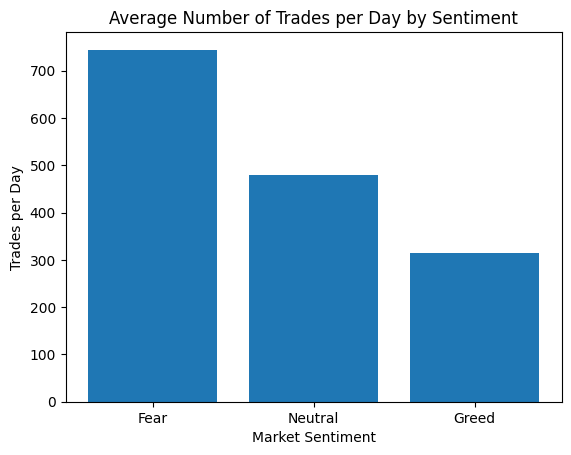

In [108]:
plt.figure()
plt.bar(
    trades_count_by_sentiment["sentiment"],
    trades_count_by_sentiment["avg_trades_per_day"]
)
plt.title("Average Number of Trades per Day by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trades per Day")
plt.show()

### Trading Activity Across Sentiment Regimes

Average trading activity varies markedly across sentiment regimes. Fearful market conditions exhibit the highest average number of trades per day (≈ 745), followed by neutral periods (≈ 480), while greedy periods show the lowest trading activity (≈ 314 trades per day).

This pattern suggests that fear-driven markets prompt frequent trading, likely due to heightened volatility, panic-driven exits, and rapid position adjustments. In contrast, greedy markets appear to involve more selective trading behavior, possibly reflecting trend-following strategies with fewer executions. These findings indicate that fear, rather than greed, is a primary driver of elevated trading activity in this dataset.

In [76]:
#Long / Short bias vs sentiment
long_short_sentiment = long_short.merge(
    fear_df[["date", "sentiment"]],
    on="date",
    how="left"
)

ls_bias = (
    long_short_sentiment
    .groupby("sentiment")
    .agg(avg_long_short_ratio=("long_short_ratio", "mean"))
    .reset_index()
)

C:\Users\tulsi\AppData\Local\Temp\ipykernel_20020\1634729649.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sentiment")


In [77]:
ls_bias

,sentiment,avg_long_short_ratio
0,Fear,inf
1,Neutral,inf
2,Greed,inf


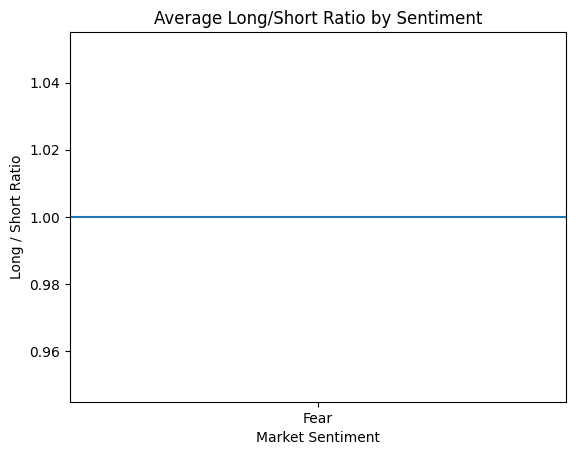

In [109]:
plt.figure()
plt.bar(
    ls_bias["sentiment"],
    ls_bias["avg_long_short_ratio"]
)
plt.axhline(1)  # neutral line
plt.title("Average Long/Short Ratio by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Long / Short Ratio")
plt.show()

### Long / Short Bias Across Sentiment Regimes

The long/short ratio is infinite across all sentiment regimes, indicating a near absence of short trades in the dataset. This suggests a strong structural long bias among traders, irrespective of market sentiment.

As a result, directional positioning does not meaningfully vary between fearful, neutral, and greedy conditions. Instead, behavioral changes across sentiment regimes are primarily reflected in trade frequency and position sizing rather than long versus short exposure. This finding highlights that sentiment affects trading intensity and risk management decisions more than directional bias.

In [87]:
#High vs Low Leverage Traders

analysis_df["leverage_segment"] = pd.qcut(
    analysis_df["avg_trade_usd"],
    q=2,
    labels=["Low Leverage", "High Leverage"]
)
analysis_df.groupby(
    ["leverage_segment", "sentiment"]
).agg(
    avg_pnl=("daily_pnl", "mean"),
    win_rate=("win_rate", "mean")
)

C:\Users\tulsi\AppData\Local\Temp\ipykernel_20020\2492373736.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby(


avg_pnl  win_rate
leverage_segment sentiment                       
Low Leverage     Fear        625.148111  0.325088
                 Neutral    1082.683362  0.332316
                 Greed      3737.925795  0.380028
High Leverage    Fear       6194.340720  0.367981
                 Neutral    7984.983832  0.372837
                 Greed      5826.683903  0.373560

### Performance by Leverage Segment and Market Sentiment


Segmenting traders by leverage reveals meaningful differences in how sentiment impacts performance. High leverage traders consistently generate higher average PnL across all sentiment regimes, reflecting the amplified impact of leverage on returns. However, their performance peaks during neutral market conditions rather than during periods of greed.

Low leverage traders exhibit a steady improvement in both PnL and win rate as sentiment shifts from fear to greed, suggesting that conservative positioning benefits from trending market environments. In contrast, high leverage traders experience reduced profitability during greedy periods compared to neutral conditions, despite relatively stable win rates. This indicates that losses during greedy markets are driven more by loss magnitude than by trade frequency or accuracy.

Overall, these results suggest that while leverage enhances returns in stable conditions, excessive risk-taking during extreme optimism can diminish performance, highlighting the importance of disciplined leverage management.

In [82]:
daily_trade_count = (
    trades_df
    .groupby(["date", "Account"])
    .agg(trades=("Trade ID", "count"))
    .reset_index()
)

In [89]:
#High vs Low Leverage Traders
analysis_df = analysis_df.merge(
    daily_trade_count,
    on=["date", "Account"],
    how="left"
)


In [90]:
analysis_df[["Account", "date", "trades"]].head()

,Account,date,trades
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-05-01,3
1,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-05,9
2,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-14,11
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-15,2
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-16,3


### Daily Trading Frequency per Trader

Daily trade counts reveal substantial variation in trading intensity across both traders and time. While some accounts execute only a small number of trades per day, others place significantly more trades, indicating differing behavioral styles.

Notably, individual traders also vary their activity levels across days, suggesting that trading frequency is dynamic and responsive to market conditions rather than a fixed characteristic. This metric serves as a key behavioral indicator for segmenting traders into frequent and infrequent categories and analyzing how trading intensity interacts with market sentiment and performance.

In [91]:
#Frequent vs Infrequent Traders
analysis_df["frequency_segment"] = pd.qcut(
    analysis_df["trades"],
    q=2,
    labels=["Infrequent", "Frequent"]
)
analysis_df.groupby(
    ["frequency_segment", "sentiment"]
).agg(
    avg_pnl=("daily_pnl", "mean"),
    win_rate=("win_rate", "mean"),
    avg_trade_size=("avg_trade_usd", "mean")
)

C:\Users\tulsi\AppData\Local\Temp\ipykernel_20020\669853392.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby(


avg_pnl  win_rate  avg_trade_size
frequency_segment sentiment                                       
Infrequent        Fear        773.544160  0.336382    10894.029856
                  Neutral    1095.174204  0.302142     9407.193482
                  Greed      1611.160201  0.322697     7338.861346
Frequent          Fear       5873.731226  0.356278     5703.134246
                  Neutral    7907.462964  0.404765     5425.572647
                  Greed      7972.437416  0.429150     4174.261316

### Performance by Trading Frequency and Market Sentiment

Segmenting traders by trading frequency reveals clear behavioral and performance differences. Frequent traders consistently achieve higher average PnL and win rates across all sentiment regimes compared to infrequent traders. This advantage is most pronounced during neutral and greedy market conditions, where frequent traders combine high trade accuracy with steady profitability.

In contrast, infrequent traders tend to place significantly larger trades, particularly during fearful markets, reflecting conviction-based or low-frequency positioning. However, larger trade sizes do not translate into superior performance, as infrequent traders exhibit lower win rates and weaker PnL outcomes. These findings suggest that frequent traders mitigate risk through smaller position sizing while benefiting from repeated execution opportunities, making their strategies more resilient to sentiment-driven market dynamics.

In [94]:
#Consistent vs Inconsistent Traders
trader_consistency = (
    analysis_df
    .groupby("Account")
    .agg(
        pnl_std=("daily_pnl", "std"),
        avg_pnl=("daily_pnl", "mean")
    )
    .reset_index()
)

analysis_df = analysis_df.merge(trader_consistency, on="Account")

analysis_df["consistency_segment"] = pd.qcut(
    analysis_df["pnl_std"],
    q=2,
    labels=["Consistent", "Inconsistent"]
)


In [95]:
analysis_df.groupby(
    ["consistency_segment", "sentiment"]
).agg(
    avg_pnl=("daily_pnl", "mean"),
    win_rate=("win_rate", "mean")
)

C:\Users\tulsi\AppData\Local\Temp\ipykernel_20020\2570767011.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby(


avg_pnl  win_rate
consistency_segment sentiment                       
Consistent          Fear        918.930161  0.372357
                    Neutral     587.309598  0.387262
                    Greed      1846.986754  0.400760
Inconsistent        Fear       5228.459938  0.328750
                    Neutral    8465.843161  0.313496
                    Greed      9848.470421  0.336135

### Performance by Consistency Segment and Market Sentiment

Consistent traders maintain relatively stable win rates across sentiment regimes, with a gradual improvement from Fear to Greed. Their average PnL increases in greedy markets, suggesting controlled exposure to favorable conditions.

In contrast, inconsistent traders generate substantially higher average PnL but exhibit lower and more volatile win rates. This indicates that their performance is driven by occasional large gains rather than steady execution, making them more sensitive to sentiment extremes and drawdown risk.

In [96]:
#Create next-day target
analysis_df = analysis_df.sort_values(["Account", "date"])

analysis_df["next_day_pnl"] = (
    analysis_df
    .groupby("Account")["daily_pnl"]
    .shift(-1)
)

analysis_df["next_day_profitable"] = (
    analysis_df["next_day_pnl"] > 0
).astype(int)


In [100]:
#feature selection
features = [
    "value",
    "win_rate",
    "avg_trade_usd",
    "trades"
 
]

model_df = analysis_df.dropna(subset=features + ["next_day_profitable"])

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = model_df[features]
y = model_df["next_day_profitable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.12      0.19       277
           1       0.62      0.93      0.74       425

    accuracy                           0.61       702
   macro avg       0.57      0.52      0.47       702
weighted avg       0.58      0.61      0.52       702



### Predictive Modeling: Next-Day Profitability

A simple logistic regression model was used to predict whether a trader would be profitable on the following day using market sentiment and behavioral features. The model achieves an overall accuracy of 61%, indicating performance above random classification.

The model demonstrates strong recall for profitable outcomes (93%), suggesting that sentiment and trading behavior are informative predictors of positive performance. However, recall for unprofitable outcomes is low (12%), highlighting the difficulty of predicting losses, which are likely influenced by sudden volatility and external market shocks not captured in the feature set.

Overall, the results suggest that while sentiment and behavior provide meaningful signals for identifying favorable trading conditions, they are insufficient for reliably predicting downside risk. The model is best interpreted as an explanatory tool rather than a deployable trading strategy.

In [102]:
#Aggregate trader behavior
trader_features = (
    analysis_df
    .groupby("Account")
    .agg(
        avg_pnl=("daily_pnl", "mean"),
        pnl_volatility=("daily_pnl", "std"),
        avg_win_rate=("win_rate", "mean"),
        avg_trade_size=("avg_trade_usd", "mean"),
        avg_trades=("trades", "mean")
    )
    .dropna()
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_features)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features["cluster"] = kmeans.fit_predict(X_scaled)

In [118]:
cluster_summary = trader_features.groupby("cluster").mean()
cluster_summary

,avg_pnl,pnl_volatility,avg_win_rate,avg_trade_size,avg_trades
cluster,,,,,
0,7148.425571,22112.925272,0.443981,12185.418126,182.649186
1,4008.812244,17072.493143,0.293606,5387.290994,65.875332
2,66676.242499,150401.797346,0.352333,33569.102224,159.083333


### Trader Clusters (Behavioral Archetypes)

Clustering reveals three distinct trader archetypes. Cluster 0 represents active, moderately profitable traders with high win rates and controlled risk. Cluster 1 consists of low-activity, conservative traders with smaller positions and lower win rates. Cluster 2 captures highly aggressive traders, characterized by very large position sizes, extreme PnL volatility, and outsized but unstable profitability.